# BOLD5000: K-Means Clustering on 414-Region Brain Graphs


In [2]:
# 1. Imports and Setup
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# 2. Load Mapping Ontology
with open('SemanticLabels.json', 'r') as f:
    ontology = json.load(f)

# Create a reverse mapping for easy lookup
label_to_broad_cat = {}
for broad_cat, details in ontology.items():
    for lbl in details['labels']:
        label_to_broad_cat[lbl.lower()] = broad_cat

print(f"Loaded {len(ontology.keys())} broad categories: {list(ontology.keys())}")

Loaded 7 broad categories: ['person', 'food', 'vehicle', 'location', 'object', 'clothing', 'living thing']


In [3]:
# 3. Load Data from Processed NPZ Files
PROCESSED_DIR = "processed_data"
# Using just CSI1 for initial analysis to avoid inter-subject batch effects
subject = "CSI1"

npz_path = os.path.join(PROCESSED_DIR, subject, f"{subject}_schaefer414.npz")
archive = np.load(npz_path, allow_pickle=True)

betas = archive['betas']
labels = archive['labels']

print(f"Loaded {subject} data:")
print(f"Betas shape: {betas.shape} (N_trials x 414 Regions)")

# 4. Filter and Prepare Labels
X_list = []
y_labels = []
y_categories = []

skipped = 0
for i in range(len(betas)):
    trial_labels = [l.lower() for l in labels[i]]
    # Map trial labels to broad categories
    found_categories = set(
        label_to_broad_cat[l] for l in trial_labels if l in label_to_broad_cat
    )
    
    # Only keep trials that unambiguously belong to exactly ONE broad category
    if len(found_categories) == 1:
        target_category = list(found_categories)[0]
        X_list.append(betas[i])
        y_labels.append(trial_labels) # For granular details if needed
        y_categories.append(target_category)
    else:
        skipped += 1

X = np.array(X_list)
print(f"Kept {len(X)} trials pointing to single categories.")
print(f"Skipped {skipped} mixed/unknown trials.")
print(f"Final Feature Matrix X shape: {X.shape}")

# See distribution of categories
unique_cats, counts = np.unique(y_categories, return_counts=True)
print("\nCategory Distribution:")
for cat, count in zip(unique_cats, counts):
    print(f"  {cat}: {count}")

Loaded CSI1 data:
Betas shape: (5254, 414) (N_trials x 414 Regions)
Kept 3919 trials pointing to single categories.
Skipped 1335 mixed/unknown trials.
Final Feature Matrix X shape: (3919, 414)

Category Distribution:
  clothing: 155
  food: 130
  living thing: 1216
  location: 1010
  object: 986
  person: 106
  vehicle: 316



Running PCA...
Explained variance ratio of top 2 PCs: 0.1497
Explained variance ratio of top 2 PCs: 0.1497


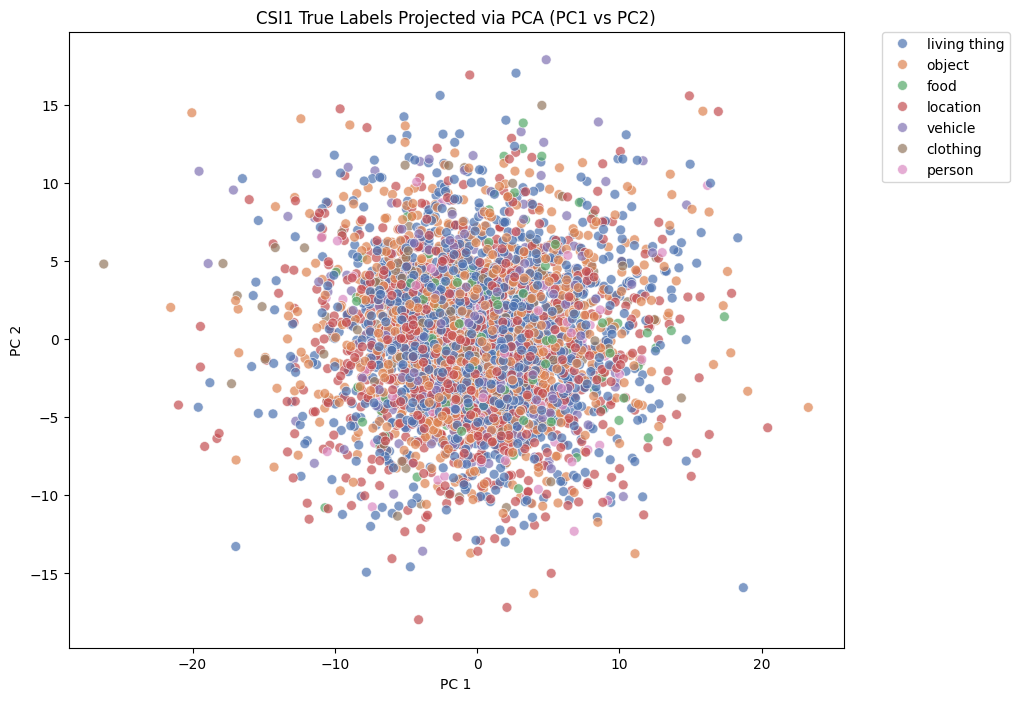


Running t-SNE...


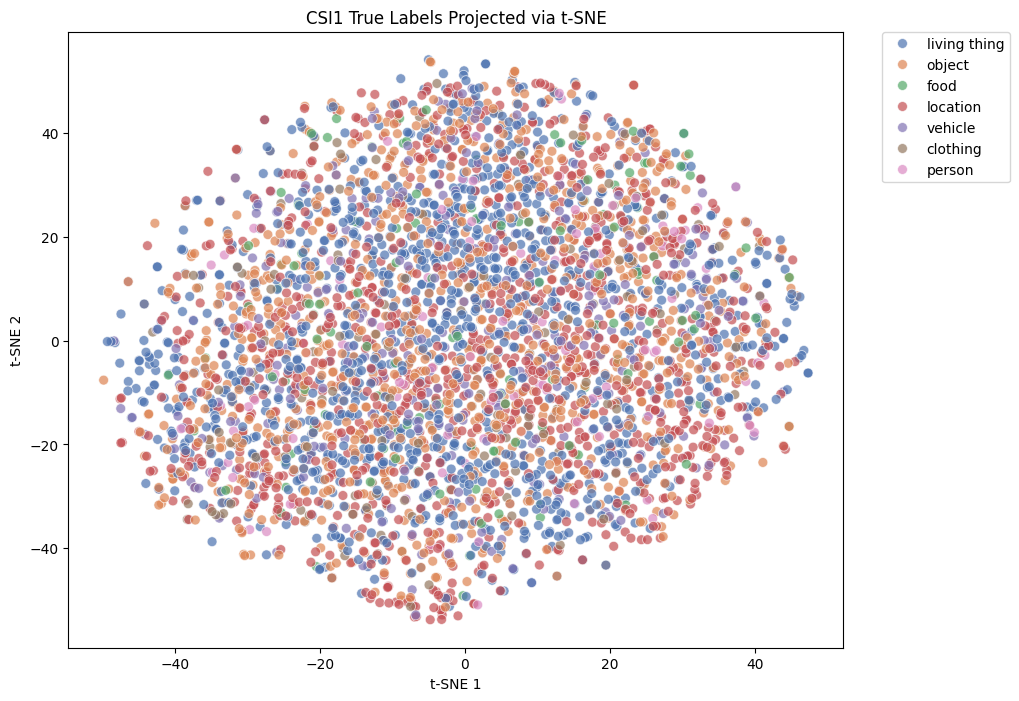


Running K-Means with k=7 clusters on scaled 414-D beta values...


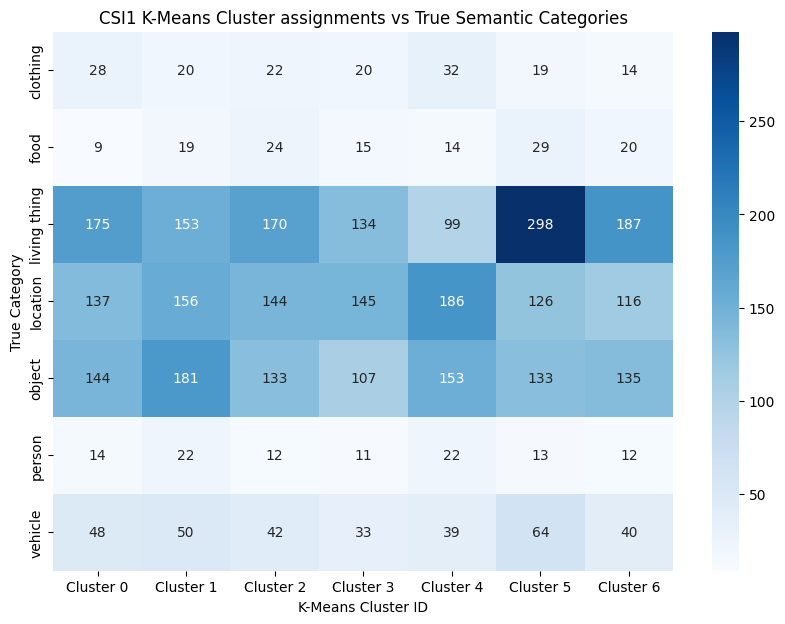

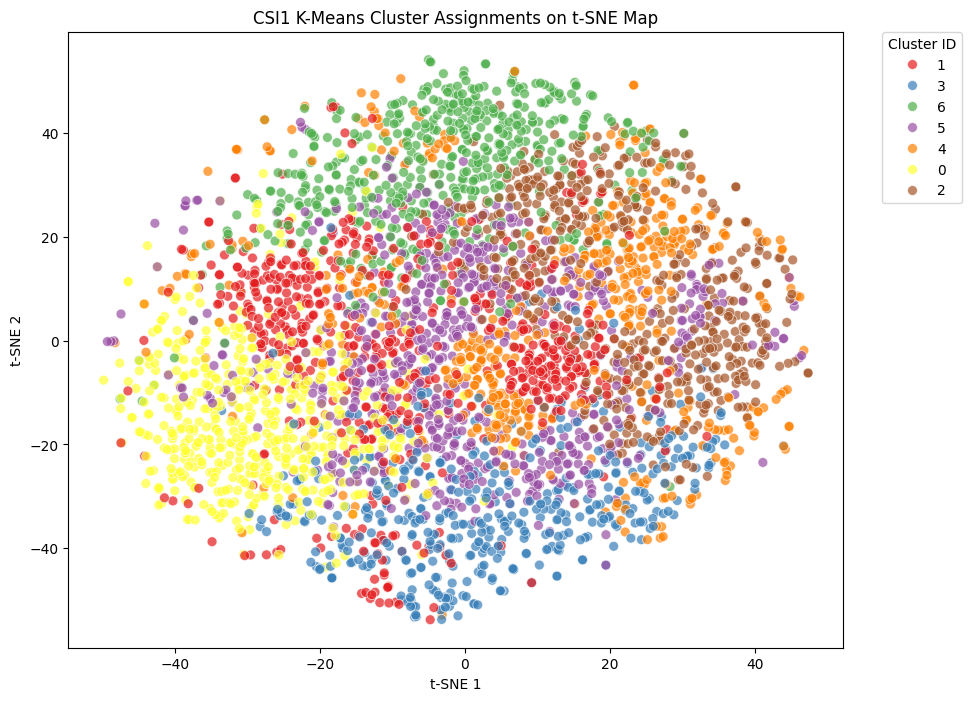

In [4]:
# 5. Dimensionality Reduction (PCA and TSNE) for visual inspection

# Step 5a: Scale the Data 
# BOLD fMRI Betas need to be standard scaled so high variance regions don't dominate clustering distances.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nRunning PCA...")
pca = PCA(n_components=50) # Keep 50 dimensions first for t-SNE input
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance ratio of top 2 PCs: {sum(pca.explained_variance_ratio_[:2]):.4f}")

# Plot top 2 Principal Components colored by true label
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=y_categories,
    palette="deep", s=50, alpha=0.7
)
plt.title(f"{subject} True Labels Projected via PCA (PC1 vs PC2)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

print("\nRunning t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca) # t-SNE handles 50 PCs well

# Plot t-SNE map colored by true label
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y_categories,
    palette="deep", s=50, alpha=0.7
)
plt.title(f"{subject} True Labels Projected via t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

#  K-Means Clustering
#See if K-Means unsupervised clustering recovers our semantic groups organically.

n_clusters = len(unique_cats) # Should be 5 based on the semantic ontology
print(f"\nRunning K-Means with k={n_clusters} clusters on scaled 414-D beta values...")

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_assignments = kmeans.fit_predict(X_scaled)

# Convert integer cluster assignments to strings so they match target y_categories typing
cluster_assignments_str = [f"Cluster {i}" for i in cluster_assignments]

# Evaluate alignment with True labels (Contingency Matrix)
from sklearn.metrics import confusion_matrix
import pandas as pd

conf_mat = confusion_matrix(y_categories, cluster_assignments_str, labels=list(unique_cats) + [f"Cluster {i}" for i in range(n_clusters)])
# Trim the matrix to just show true categories along index, clusters along columns
df_cm = pd.DataFrame(
    conf_mat[:len(unique_cats), len(unique_cats):], 
    index=unique_cats, 
    columns=[f"Cluster {i}" for i in range(n_clusters)]
)

plt.figure(figsize=(10, 7))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")
plt.title(f"{subject} K-Means Cluster assignments vs True Semantic Categories")
plt.ylabel("True Category")
plt.xlabel("K-Means Cluster ID")
plt.show()

# Plot the K-Means clusters superimposed on the t-SNE plot to see how they laid out
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=[str(c) for c in cluster_assignments],
    palette="Set1", s=50, alpha=0.7
)
plt.title(f"{subject} K-Means Cluster Assignments on t-SNE Map")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

=== Clustering Evaluation Metrics ===
Normalized Mutual Information (NMI) : 0.0119
Adjusted Rand Index (ARI)         : 0.0090
overall Silhouette Score          : 0.0241
Normalized Mutual Information (NMI) : 0.0119
Adjusted Rand Index (ARI)         : 0.0090
overall Silhouette Score          : 0.0241


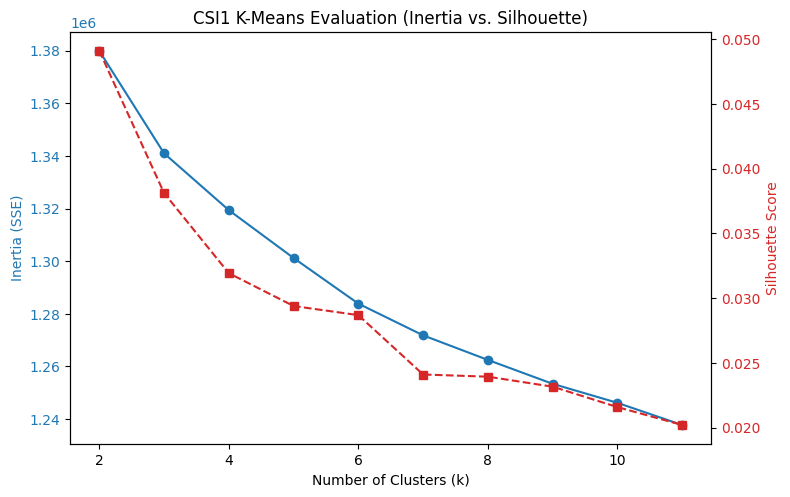

In [5]:
# 7. Evaluate the Clustering Structure 
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score

print("=== Clustering Evaluation Metrics ===")
# NMI: How well does K-Means match our true semantic ontology? (0=Random, 1=Perfect)
nmi = normalized_mutual_info_score(y_categories, cluster_assignments)

# ARI: Adjusted Rand Index (how many pairs are put in the same cluster/different cluster correctly)
ari = adjusted_rand_score(y_categories, cluster_assignments)

# Silhouette Score: Are the clusters well-separated geometrically in the 414-D space?
sil_score = silhouette_score(X_scaled, cluster_assignments)

print(f"Normalized Mutual Information (NMI) : {nmi:.4f}")
print(f"Adjusted Rand Index (ARI)         : {ari:.4f}")
print(f"overall Silhouette Score          : {sil_score:.4f}")

# Finding Optimal K Using Elbow Method and Silhouette Analysis
sil_scores = []
kinertias = []
k_range = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    preds = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, preds))
    kinertias.append(km.inertia_)

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (SSE)', color=color)
ax1.plot(k_range, kinertias, 'o-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)  
ax2.plot(k_range, sil_scores, 's--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.title(f"{subject} K-Means Evaluation (Inertia vs. Silhouette)")
plt.show()

In [6]:
# 6.1 Inspect clusters: print which labels/categories are in each K-Means cluster
from collections import Counter, defaultdict

# cluster_assignments: np.ndarray[int] of shape (n_samples,)
# y_categories: list[str] broad category per sample (your "true" category)
# y_labels: list[list[str]] granular labels per sample

def _fmt_top(counter: Counter, k: int = 8):
    return ", ".join([f"{name} ({cnt})" for name, cnt in counter.most_common(k)])

# Build per-cluster indices
cluster_to_idx = defaultdict(list)
for i, c in enumerate(cluster_assignments):
    cluster_to_idx[int(c)].append(i)

print("\n=== Cluster label inspection ===")
for c in sorted(cluster_to_idx.keys()):
    idxs = cluster_to_idx[c]
    cats = [y_categories[i] for i in idxs]
    cat_counts = Counter(cats)
    # Flatten granular labels (if you want the raw labels list per trial)
    flat_labels = []
    for i in idxs:
        flat_labels.extend(y_labels[i])
    label_counts = Counter(flat_labels)

    print(f"\nCluster {c}: n={len(idxs)}")
    print("  Top true categories:", _fmt_top(cat_counts, k=10))
    print("  Top granular labels:", _fmt_top(label_counts, k=15))

    # Show a few example trials from the cluster
    print("  Example trials (granular labels):")
    for i in idxs[:10]:
        print("   -", y_categories[i], "|", y_labels[i])


=== Cluster label inspection ===

Cluster 0: n=555
  Top true categories: living thing (175), object (144), location (137), vehicle (48), clothing (28), person (14), food (9)
  Top granular labels: zebra (13), vase (13), clock (12), bird (11), airplane (11), person (9), potted plant (8), chair (7), giraffe (7), train (7), book (6), cow (6), dining table (6), sheep (5), couch (5)
  Example trials (granular labels):
   - location | ['church']
   - living thing | ['zebra']
   - living thing | ['ant']
   - object | ['fireplace']
   - living thing | ['three-toed_sloth']
   - location | ['nailsalon']
   - object | ['oil_filter']
   - person | ['person', 'teddy bear']
   - object | ['wooden_spoon']
   - object | ['pick']

Cluster 1: n=601
  Top true categories: object (181), location (156), living thing (153), vehicle (50), person (22), clothing (20), food (19)
  Top granular labels: person (15), potted plant (14), chair (14), dining table (13), vase (11), sink (10), cup (10), clock (10), te